<a href="https://colab.research.google.com/github/SirisPudasai/ML/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1=pd.read_csv('/content/application_record.csv')
df2=pd.read_csv('/content/credit_record.csv')
df=pd.merge(df1,df2)

In [ ]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [ ]:
df.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
df.shape


(777715, 20)

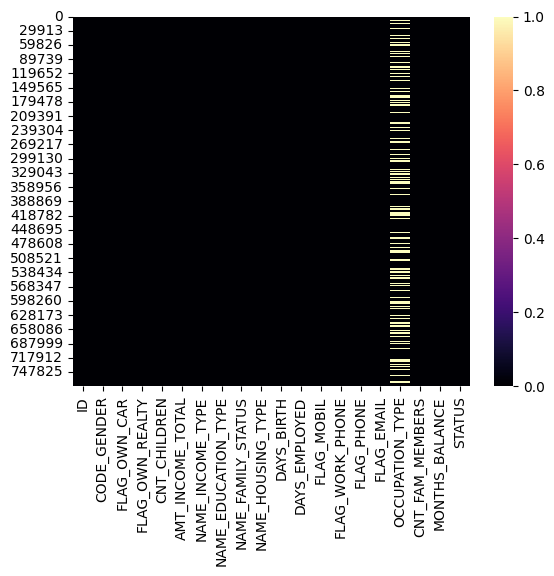

In [ ]:
sns.heatmap(df.isna(),cmap='magma')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  object 
 2   FLAG_OWN_CAR         777715 non-null  object 
 3   FLAG_OWN_REALTY      777715 non-null  object 
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  object 
 7   NAME_EDUCATION_TYPE  777715 non-null  object 
 8   NAME_FAMILY_STATUS   777715 non-null  object 
 9   NAME_HOUSING_TYPE    777715 non-null  object 
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE
count,7.777150e+05,777715.000000,7.777150e+05,777715.000000,777715.000000,777715.0,777715.000000,777715.000000,777715.000000,777715.000000,777715.000000
mean,5.078743e+06,0.428082,1.885348e+05,-16124.937046,57775.825016,1.0,0.231818,0.300965,0.091675,2.208837,-19.373564
std,4.180442e+04,0.745755,1.016225e+05,4104.304018,136471.735391,0.0,0.421993,0.458678,0.288567,0.907380,14.082208
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,-60.000000
25%,5.044568e+06,0.000000,1.215000e+05,-19453.000000,-3292.000000,1.0,0.000000,0.000000,0.000000,2.000000,-29.000000
50%,5.069530e+06,0.000000,1.620000e+05,-15760.000000,-1682.000000,1.0,0.000000,0.000000,0.000000,2.000000,-17.000000
75%,5.115551e+06,1.000000,2.250000e+05,-12716.000000,-431.000000,1.0,0.000000,1.000000,0.000000,3.000000,-8.000000
max,5.150487e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,0.000000


In [ ]:
df['has_target_status'] = df['STATUS'].isin(['2', '3', '4', '5']).astype(int)
cpunt = df.groupby('ID')['has_target_status'].max().reset_index()
cpunt.rename(columns={'dep_value': 'target'}, inplace=True)
new_data = pd.merge(df, cpunt, how='inner', on='ID')

In [ ]:
df


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,has_target_status
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,0,C,0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,-1,C,0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,-2,C,0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,-3,C,0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,-4,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,-1193,1,0,0,0,Laborers,1.0,-9,0,0
777711,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,-1193,1,0,0,0,Laborers,1.0,-10,2,1
777712,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,-1193,1,0,0,0,Laborers,1.0,-11,1,0
777713,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,...,-1193,1,0,0,0,Laborers,1.0,-12,0,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
df['AMT_INCOME_TOTAL'] = scale.fit_transform(df[['AMT_INCOME_TOTAL']])

In [ ]:
from sklearn.preprocessing import LabelEncoder

len = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = len.fit_transform(df[col].astype(str))

In [ ]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,has_target_status
0,5008804,1,1,1,0,0.258721,4,1,0,4,...,-4542,1,1,0,0,18,2.0,0,6,0
1,5008804,1,1,1,0,0.258721,4,1,0,4,...,-4542,1,1,0,0,18,2.0,-1,6,0
2,5008804,1,1,1,0,0.258721,4,1,0,4,...,-4542,1,1,0,0,18,2.0,-2,6,0
3,5008804,1,1,1,0,0.258721,4,1,0,4,...,-4542,1,1,0,0,18,2.0,-3,6,0
4,5008804,1,1,1,0,0.258721,4,1,0,4,...,-4542,1,1,0,0,18,2.0,-4,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,1,0,1,0,0.055233,4,4,3,4,...,-1193,1,0,0,0,8,1.0,-9,0,0
777711,5150337,1,0,1,0,0.055233,4,4,3,4,...,-1193,1,0,0,0,8,1.0,-10,2,1
777712,5150337,1,0,1,0,0.055233,4,4,3,4,...,-1193,1,0,0,0,8,1.0,-11,1,0
777713,5150337,1,0,1,0,0.055233,4,4,3,4,...,-1193,1,0,0,0,8,1.0,-12,0,0


In [ ]:
df.fillna(df.mean(), inplace=True)

In [ ]:
df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)
df['DAYS_EMPLOYED'] = (-df['DAYS_EMPLOYED'] / 365).astype(int)
df['MONTHS_BALANCE'] = (-df['MONTHS_BALANCE'] / 12).astype(int)
df.drop(columns=['DAYS_BIRTH'], inplace=True)

In [ ]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,has_target_status,AGE_YEARS
0,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,1,0,0,18,2.0,0,6,0,32
1,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,1,0,0,18,2.0,0,6,0,32
2,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,1,0,0,18,2.0,0,6,0,32
3,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,1,0,0,18,2.0,0,6,0,32
4,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,1,0,0,18,2.0,0,6,0,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150337,1,0,1,0,0.055233,4,4,3,4,...,1,0,0,0,8,1.0,0,0,0,25
777711,5150337,1,0,1,0,0.055233,4,4,3,4,...,1,0,0,0,8,1.0,0,2,1,25
777712,5150337,1,0,1,0,0.055233,4,4,3,4,...,1,0,0,0,8,1.0,0,1,0,25
777713,5150337,1,0,1,0,0.055233,4,4,3,4,...,1,0,0,0,8,1.0,1,0,0,25


In [ ]:
df['AGE_YEARS'].value_counts().sort_index()

,count
AGE_YEARS,
20,1
21,89
22,1597
23,2288
24,5672
25,7800
26,9992
27,21802
28,21688


<Axes: >

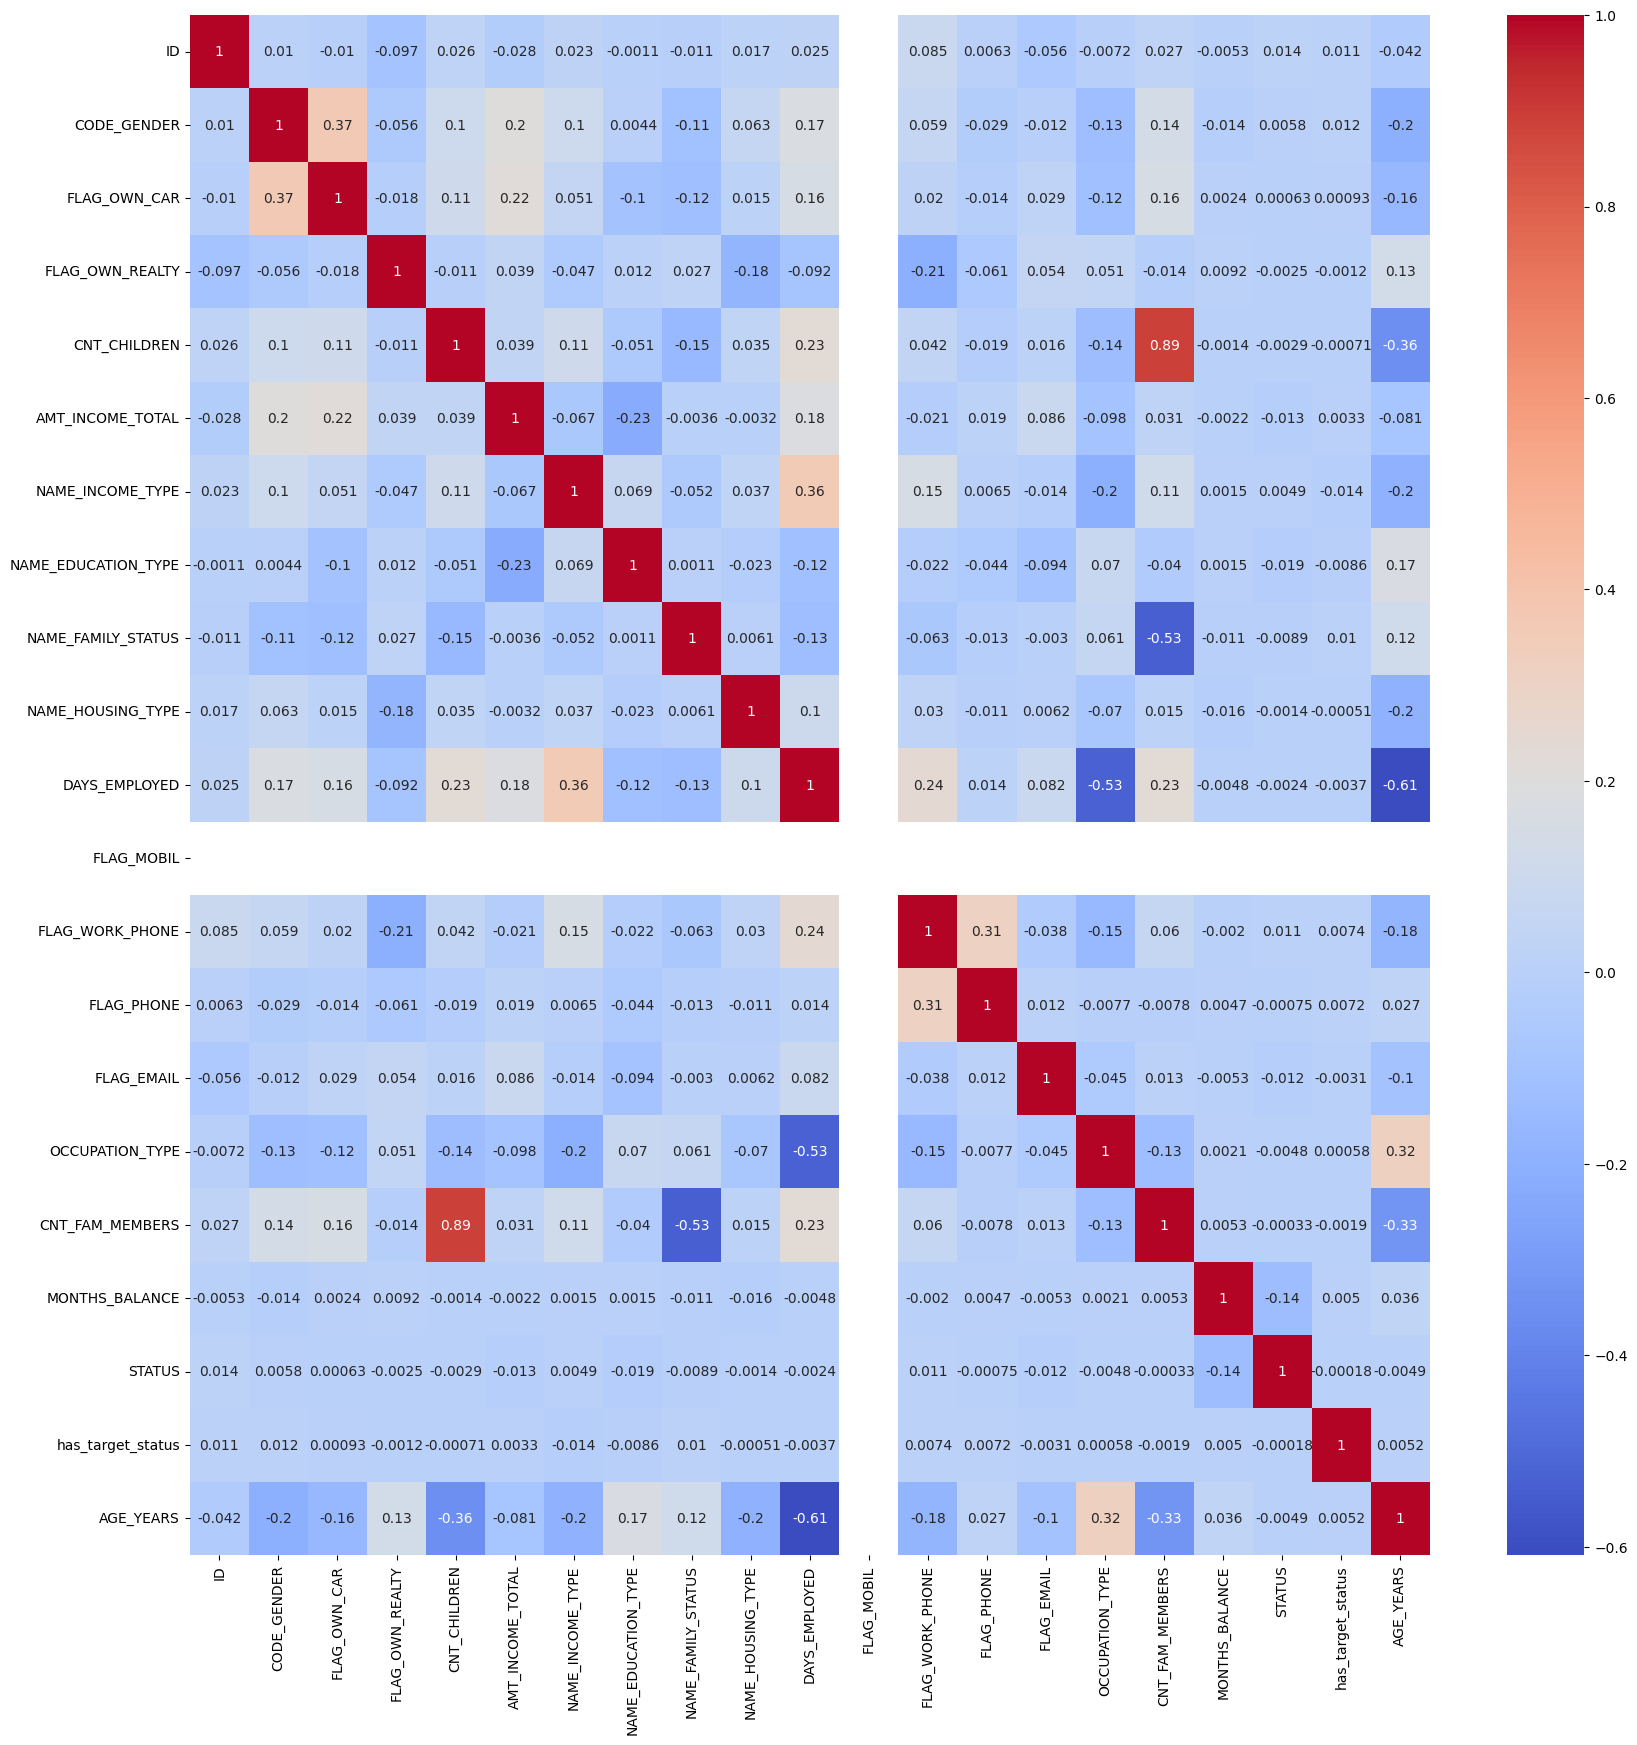

In [ ]:
fig = plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=True, cmap='magma')

In [ ]:
df['Target'] = df['STATUS'].replace({'C': 0, 'X': 0}).astype(str)
df['Target'] = df['Target'].astype(int)
df['Target'] = (df['Target'] >= 3).astype(int)

<Axes: xlabel='Target'>

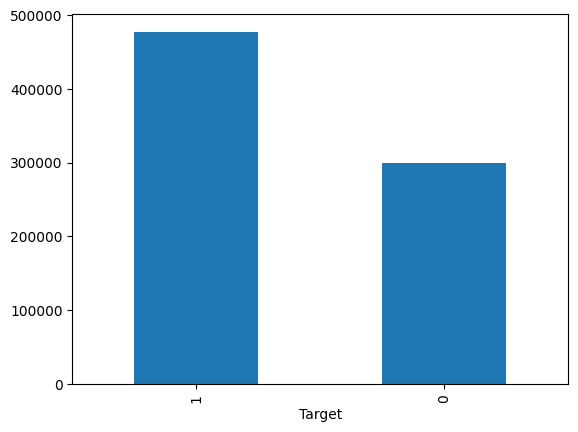

In [ ]:
df['Target'].value_counts().plot(kind='bar')

In [ ]:
from collections import Counter
target_counts = Counter(df['Target'])
print("Target value counts:", target_counts)

Target value counts: Counter({1: 477513, 0: 300202})


In [ ]:
df_target0 = df[df['Target'] == 0]
df_target1 = df[df['Target'] == 1]

In [ ]:
df_tsrget1 = df_target1.sample(n=len(df_target0), random_state=42)

In [ ]:
df_tsrget1.shape

(300202, 22)

In [ ]:
df_target0.shape

(300202, 22)

<Axes: xlabel='Target'>

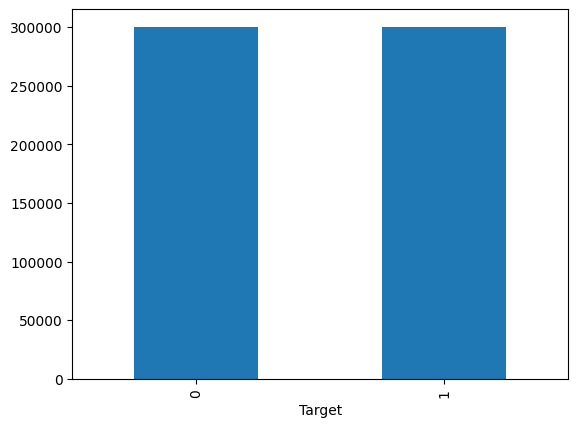

In [ ]:
df = pd.concat([df_target0, df_tsrget1], axis=0)
df['Target'].value_counts().plot(kind='bar')

In [ ]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,has_target_status,AGE_YEARS,Target
13,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,0,0,18,2.0,1,1,0,32,0
14,5008804,1,1,1,0,0.258721,4,1,0,4,...,1,0,0,18,2.0,1,0,0,32,0
28,5008805,1,1,1,0,0.258721,4,1,0,4,...,1,0,0,18,2.0,1,1,0,32,0
29,5008805,1,1,1,0,0.258721,4,1,0,4,...,1,0,0,18,2.0,1,0,0,32,0
39,5008806,1,1,1,0,0.055233,4,4,1,1,...,0,0,0,16,2.0,0,0,0,58,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460803,5091288,0,0,1,0,0.101744,1,4,3,1,...,0,0,0,18,1.0,1,7,0,67,1
624842,5117519,0,0,0,1,0.075581,4,4,3,4,...,1,1,0,6,2.0,0,7,0,39,1
336916,5062618,1,1,1,0,0.156977,2,4,1,1,...,0,0,0,3,2.0,2,6,0,31,1
129715,5029188,1,1,1,0,0.107558,2,1,1,1,...,0,1,0,6,2.0,1,6,0,48,1


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Target', 'STATUS'])
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((480323, 20), (120081, 20), (480323,), (120081,))

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
model.score(X_test, y_test)

0.5599720188872511

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)
rf_model.score(X_test, y_test)

0.8683305435497706

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix =confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87     60041
           1       0.89      0.84      0.87     60040

    accuracy                           0.87    120081
   macro avg       0.87      0.87      0.87    120081
weighted avg       0.87      0.87      0.87    120081



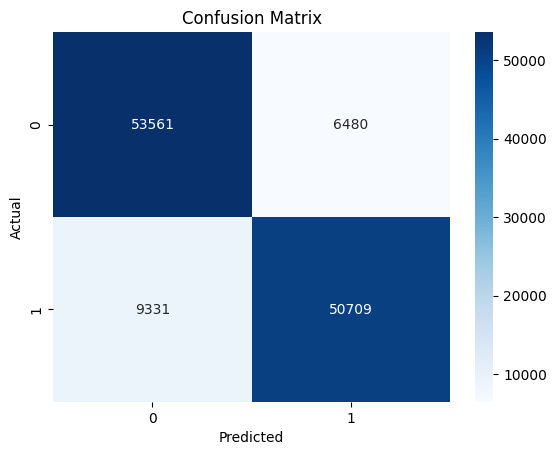

In [ ]:
# Using already computed confusion matrix
cm = confusion_matrix

# Plot the confusion matrix as a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_model.score(X_test, y_test)
from sklearn.metrics import classification_report, confusion_matrix
y_pred = dt_model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix =confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.84      0.91      0.88     60041
           1       0.90      0.83      0.87     60040

    accuracy                           0.87    120081
   macro avg       0.87      0.87      0.87    120081
weighted avg       0.87      0.87      0.87    120081

